In [5]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "../sam3")

import torch

In [6]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [7]:
bpe_path = f"../sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

In [8]:
image_path = f"../segmentation/sample_segmentation_img.png"
image = Image.open(image_path).convert("RGB")
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

found 9 object(s)


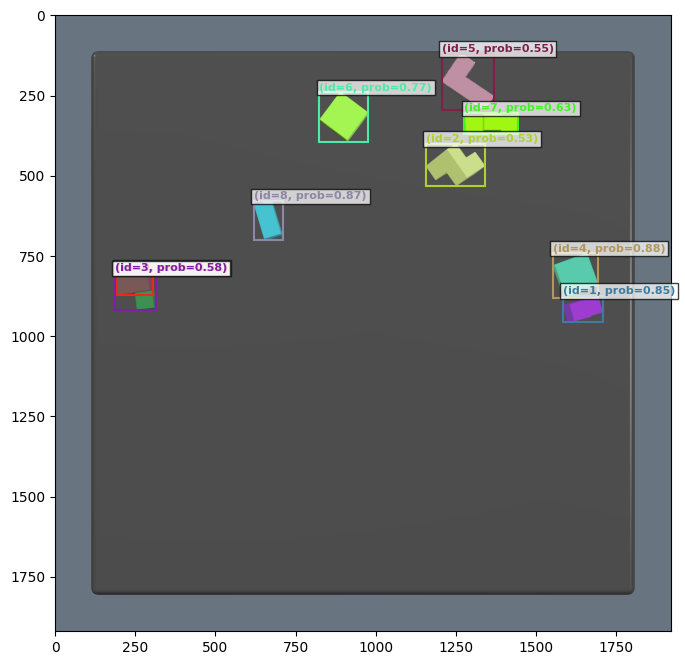

In [9]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="all the objects in different colors")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [49]:
inference_state["masks"]

tensor([[[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]],


        [[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]],


        [[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, Fa

In [ ]:
def nms(boxes, scores, iou_threshold=0.5):
    import torch
    if not isinstance(boxes, torch.Tensor):
        boxes = torch.tensor(boxes, dtype=torch.float32)
    if not isinstance(scores, torch.Tensor):
        scores = torch.tensor(scores, dtype=torch.float32)

    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort(descending=True)

    kept = []
    while order.numel() > 0:
        i = order[0].item()
        kept.append(i)

        if order.numel() == 1:
            break

        inter_x1 = x1[order[1:]].clamp(min=x1[i])
        inter_y1 = y1[order[1:]].clamp(min=y1[i])
        inter_x2 = x2[order[1:]].clamp(max=x2[i])
        inter_y2 = y2[order[1:]].clamp(max=y2[i])

        inter = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        order = order[1:][iou <= iou_threshold]

    return kept


kept_indices = nms(inference_state["boxes"], inference_state["scores"], iou_threshold=0.5)
# kept_boxes = [inference_state["boxes"][i] for i in kept_indices]

In [45]:
kept_boxes = [i.cpu().numpy() for i in kept_boxes]

In [52]:
segment_maps = [inference_state["masks"][i].cpu().numpy() for i in kept_indices]

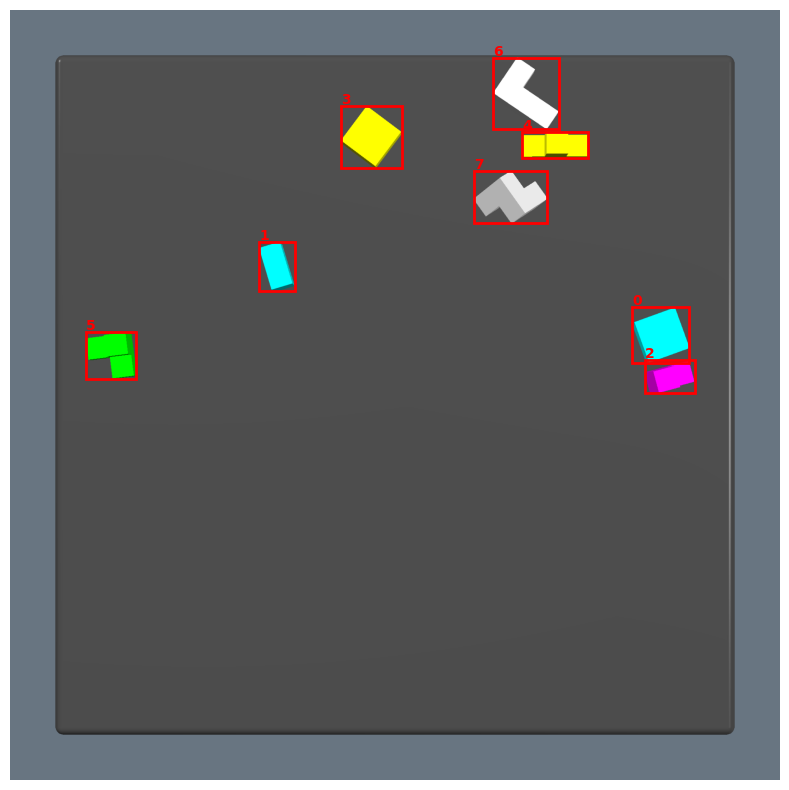

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

def plot_boxes(image, boxes):
    if isinstance(image, str):
        image = Image.open(image)
    
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.detach().cpu().numpy()

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)

    for i, (x1, y1, x2, y2) in enumerate(boxes):
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, str(i), color='red', fontsize=10, fontweight='bold')

    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Usage
plot_boxes("../segmentation/sample_segmentation_img.png", kept_boxes)